# Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# Questions:

- Can we predict whether a youth has used marijuana in the past year based on demographic and social factors?
- Can we predict the level of marijuana use (none, low, medium, high) among youth based on demographic and social factors?
- Can we predict alcohol use days among youth who reported using alcohol based on demographic and social factors?


# Data Processing

## Access data from github

In [ ]:
# Youth data
youth_url = "https://raw.githubusercontent.com/mendible/5322/main/Homework%201/youth_data.csv"
df = pd.read_csv(youth_url)

print("Shape:", df.shape)
print(df.columns.tolist())


Shape: (10561, 79)
['IRALCFY', 'IRMJFY', 'IRCIGFM', 'IRSMKLSS30N', 'IRALCFM', 'IRMJFM', 'IRCIGAGE', 'IRSMKLSSTRY', 'IRALCAGE', 'IRMJAGE', 'MRJFLAG', 'ALCFLAG', 'TOBFLAG', 'ALCYDAYS', 'MRJYDAYS', 'ALCMDAYS', 'MRJMDAYS', 'CIGMDAYS', 'SMKLSMDAYS', 'SCHFELT', 'TCHGJOB', 'AVGGRADE', 'STNDSCIG', 'STNDSMJ', 'STNDALC', 'STNDDNK', 'PARCHKHW', 'PARHLPHW', 'PRCHORE2', 'PRLMTTV2', 'PARLMTSN', 'PRGDJOB2', 'PRPROUD2', 'ARGUPAR', 'YOFIGHT2', 'YOGRPFT2', 'YOHGUN2', 'YOSELL2', 'YOSTOLE2', 'YOATTAK2', 'PRPKCIG2', 'PRMJEVR2', 'PRMJMO', 'PRALDLY2', 'YFLPKCG2', 'YFLTMRJ2', 'YFLMJMO', 'YFLADLY2', 'FRDPCIG2', 'FRDMEVR2', 'FRDMJMON', 'FRDADLY2', 'TALKPROB', 'PRTALK3', 'PRBSOLV2', 'PREVIOL2', 'PRVDRGO2', 'GRPCNSL2', 'PREGPGM2', 'YTHACT2', 'DRPRVME3', 'ANYEDUC3', 'RLGATTD', 'RLGIMPT', 'RLGDCSN', 'RLGFRND', 'IRSEX', 'NEWRACE2', 'HEALTH2', 'EDUSCHLGO', 'EDUSCHGRD2', 'EDUSKPCOM', 'IMOTHER', 'IFATHER', 'INCOME', 'GOVTPROG', 'POVERTY3', 'PDEN10', 'COUTYP4']


## Narrow columns down

In [ ]:
# Columns to keep
cols = [
    "MRJYDAYS",   # recoded marijuana frequency category
    "IRALCFY",    # alcohol days in past year

    # Predictors
    "IRSEX",
    "NEWRACE2",
    "EDUSCHGRD2",
    "SCHFELT",
    "STNDSMJ",
    "PRMJEVR2",
    "FRDMJMON",
    "POVERTY3"
]

df_model = df[cols].copy()

# Force numeric
for c in df_model.columns:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

print(df_model.shape)
df_model.head()

(10561, 10)


,MRJYDAYS,IRALCFY,IRSEX,NEWRACE2,EDUSCHGRD2,SCHFELT,STNDSMJ,PRMJEVR2,FRDMJMON,POVERTY3
0,6,991,1,7,3,1,2.0,1.0,1.0,1
1,3,991,2,1,6,2,1.0,2.0,2.0,1
2,6,1,1,6,2,1,2.0,1.0,1.0,3
3,6,991,2,7,2,2,2.0,1.0,1.0,2
4,6,991,1,1,5,1,2.0,2.0,1.0,3


## Create 3 targets

In [ ]:
# Binary target
# Can we predict whether a youth has used marijuana in the past year based on demographic and social factors?
# MRJYDAYS codes:
# 1-5 = some past year marijuana use
# 6 = non-user/no past year use
df_model["target_binary"] = np.where(
    df_model["MRJYDAYS"].between(1, 5), 1,
    np.where(df_model["MRJYDAYS"] == 6, 0, np.nan)
)

df_model["target_binary"].value_counts(dropna=False)

,count
target_binary,
0.0,9226
1.0,1335


In [ ]:
# Multi-class target
# Can we predict the level of marijuana use (none, low, medium, high) among youth based on demographic and social factors?
# Use MRJYDAYS, switch to a 4 level scale due to very high imbalance in 6 level
# Still an imbalance but not nearly as bad
def categorize_mj(x):
    if x == 6:
        return 0   # no use
    elif x in [1, 2]:
        return 1   # low use
    elif x in [3, 4]:
        return 2   # medium use
    elif x == 5:
        return 3   # high use
    else:
        return np.nan

df_model["target_multi"] = df_model["MRJYDAYS"].apply(categorize_mj)

df_model["target_multi"].value_counts(dropna=False)

,count
target_multi,
0,9226
1,769
2,441
3,125


In [ ]:
# Regression target
# Can we predict alcohol use days among youth who reported using alcohol based on demographic and social factors?
df_model["target_reg"] = df_model["IRALCFY"]

# Remove non-users and special codes
df_model.loc[df_model["target_reg"].isin([991, 993]), "target_reg"] = np.nan
df_model.loc[df_model["target_reg"] >= 994, "target_reg"] = np.nan

print(df_model["target_reg"].describe())

count    1865.000000
mean       22.414477
std        40.323468
min         1.000000
25%         2.000000
50%         5.000000
75%        24.000000
max       339.000000
Name: target_reg, dtype: float64


## Final dataset

In [ ]:
# Predictors
predictors = [
    "IRSEX",
    "NEWRACE2",
    "EDUSCHGRD2",
    "SCHFELT",
    "STNDSMJ",
    "PRMJEVR2",
    "FRDMJMON",
    "POVERTY3"
]

# Treat common high special codes as missing
for c in predictors:
    df_model.loc[df_model[c] >= 90, c] = np.nan

# Split datasets by target
# Binary
df_binary = df_model.dropna(subset=["target_binary"]).copy()
X_binary_df = df_binary[predictors]
y_binary = df_binary["target_binary"].astype(int)

# Multi-class
df_multi = df_model.dropna(subset=["target_multi"]).copy()
X_multi_df = df_multi[predictors]
y_multi = df_multi["target_multi"].astype(int)

# Regression
df_reg = df_model.dropna(subset=["target_reg"]).copy()
X_reg_df = df_reg[predictors]
y_reg = df_reg["target_reg"].astype(float)

# Define feature types
categorical_cols = ["IRSEX", "NEWRACE2", "EDUSCHGRD2"]
numeric_cols = [c for c in predictors if c not in categorical_cols]

# Preprocessing pipelines
# Binary pipeline
binary_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

# Multi-class pipeline
multi_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

# Regression pipeline
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)


# Apply preprocessing
X_binary = binary_preprocessor.fit_transform(X_binary_df)
X_multi = multi_preprocessor.fit_transform(X_multi_df)
X_reg = reg_preprocessor.fit_transform(X_reg_df)

# Keep feature list for later plots
features = predictors

print("Binary shape:", X_binary.shape, y_binary.shape)
print("Multi shape:", X_multi.shape, y_multi.shape)
print("Regression shape:", X_reg.shape, y_reg.shape)

Binary shape: (10561, 21) (10561,)
Multi shape: (10561, 21) (10561,)
Regression shape: (1865, 21) (1865,)


# Model Work

## Train/test split

In [ ]:
# Binary
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_binary, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# Multi-class
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

# Regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

## Decision Tree

### Binary

In [ ]:

# A grid search with cross-validation was used to tune key hyperparameters max_depth, min_samples_leaf, and splitting criterion
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "min_samples_leaf": [10, 20, 50],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train_b, y_train_b)

print("Best params:", grid_dt.best_params_)
print("Best CV accuracy:", grid_dt.best_score_)

tree_b = grid_dt.best_estimator_
pred_b = tree_b.predict(X_test_b)

print("Decision Tree (Binary) Accuracy:", accuracy_score(y_test_b, pred_b))
print(confusion_matrix(y_test_b, pred_b))

Best params: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 50}
Best CV accuracy: 0.8945311990919315
Decision Tree (Binary) Accuracy: 0.8883104590629437
[[1789   57]
 [ 179   88]]


              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1846
           1       0.61      0.33      0.43       267

    accuracy                           0.89      2113
   macro avg       0.76      0.65      0.68      2113
weighted avg       0.87      0.89      0.87      2113

Decision Tree (Binary) ROC AUC: 0.8686886516448157


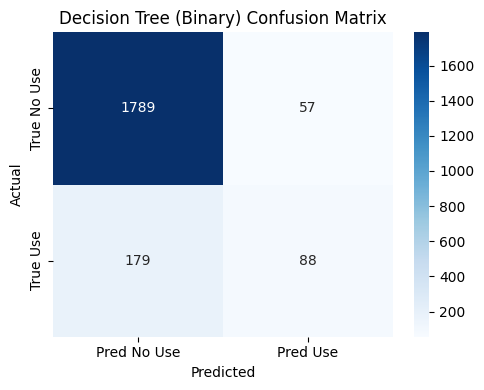

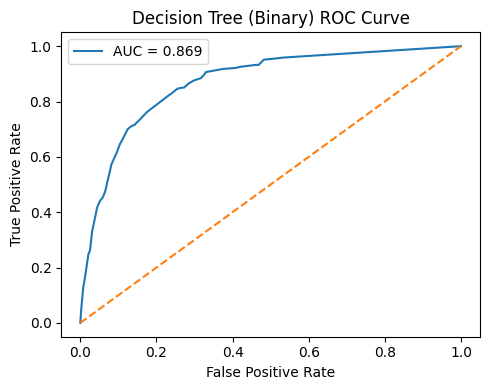

In [ ]:
# Binary model probabilities
pred_b_proba = tree_b.predict_proba(X_test_b)[:, 1]

# Extra evaluation metrics
print(classification_report(y_test_b, pred_b))
print("Decision Tree (Binary) ROC AUC:", roc_auc_score(y_test_b, pred_b_proba))

# Confusion matrix heatmap
cm_b = confusion_matrix(y_test_b, pred_b)

plt.figure(figsize=(5,4))
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred No Use", "Pred Use"],
            yticklabels=["True No Use", "True Use"])
plt.title("Decision Tree (Binary) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve
fpr_b, tpr_b, _ = roc_curve(y_test_b, pred_b_proba)

plt.figure(figsize=(5,4))
plt.plot(fpr_b, tpr_b, label=f"AUC = {roc_auc_score(y_test_b, pred_b_proba):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("Decision Tree (Binary) ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

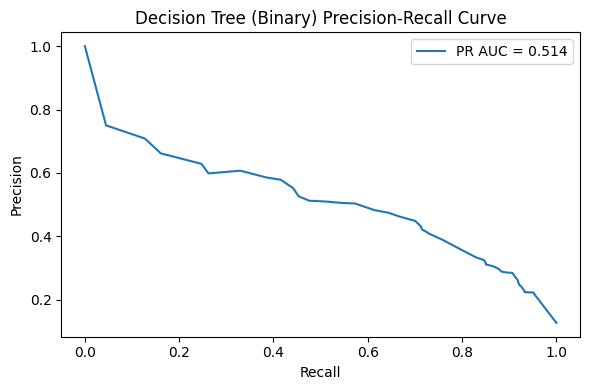

In [ ]:
# Get predicted probabilities
y_scores = tree_b.predict_proba(X_test_b)[:, 1]

# Compute precision-recall
precision, recall, _ = precision_recall_curve(y_test_b, y_scores)
pr_auc = auc(recall, precision)

# Plot
plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree (Binary) Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

### Multi-class

In [ ]:
# Hyperparameters were tuned using GridSearchCV with 5-fold cross-validation, again optimizing for accuracy
param_grid_multi = {
    "max_depth": [3, 4, 5, 6],
    "min_samples_leaf": [10, 20, 50],
    "criterion": ["gini", "entropy"]
}

grid_dt_multi = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_multi,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt_multi.fit(X_train_m, y_train_m)

print("Best multi params:", grid_dt_multi.best_params_)
print("Best multi CV accuracy:", grid_dt_multi.best_score_)

tree_m = grid_dt_multi.best_estimator_
pred_m = tree_m.predict(X_test_m)

print("\nDecision Tree (Multi) Accuracy:", accuracy_score(y_test_m, pred_m))
print(confusion_matrix(y_test_m, pred_m))

Best multi params: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 20}
Best multi CV accuracy: 0.8744079512053279

Decision Tree (Multi) Accuracy: 0.8717463322290582
[[1830   11    5    0]
 [ 145    6    3    0]
 [  74    8    6    0]
 [  23    1    1    0]]


### Regression

In [ ]:
# Hperparameters were tuned using GridSearchCV with 5-fold cross-validation, optimizing for RMSE.
param_grid_reg = {
    "max_depth": [3, 4, 5, 6, 8],
    "min_samples_leaf": [5, 10, 20, 50],
    "criterion": ["squared_error", "friedman_mse"]
}

grid_dt_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_dt_reg.fit(X_train_r, y_train_r)

print("Best reg params:", grid_dt_reg.best_params_)
print("Best reg CV RMSE:", -grid_dt_reg.best_score_)

tree_r = grid_dt_reg.best_estimator_
pred_r = tree_r.predict(X_test_r)

rmse_tree = np.sqrt(mean_squared_error(y_test_r, pred_r))
print("\nDecision Tree (Regression) RMSE:", rmse_tree)
print("Decision Tree (Regression) R^2:", r2_score(y_test_r, pred_r))

Best reg params: {'criterion': 'squared_error', 'max_depth': 4, 'min_samples_leaf': 50}
Best reg CV RMSE: 40.444567475523954

Decision Tree (Regression) RMSE: 35.6173670399263
Decision Tree (Regression) R^2: -0.04053526402859342


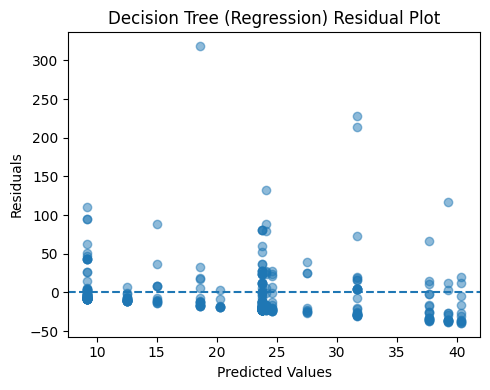

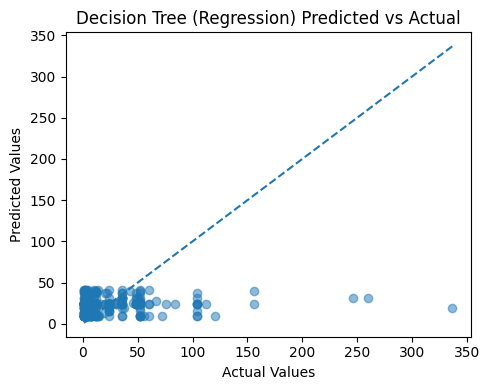

In [ ]:
# Residuals
residuals = y_test_r - pred_r

# Residual plot
plt.figure(figsize=(5,4))
plt.scatter(pred_r, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Decision Tree (Regression) Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

# Predicted vs Actual plot
plt.figure(figsize=(5,4))
plt.scatter(y_test_r, pred_r, alpha=0.5)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         linestyle="--")
plt.title("Decision Tree (Regression) Predicted vs Actual")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

## Model Comparison feature importance

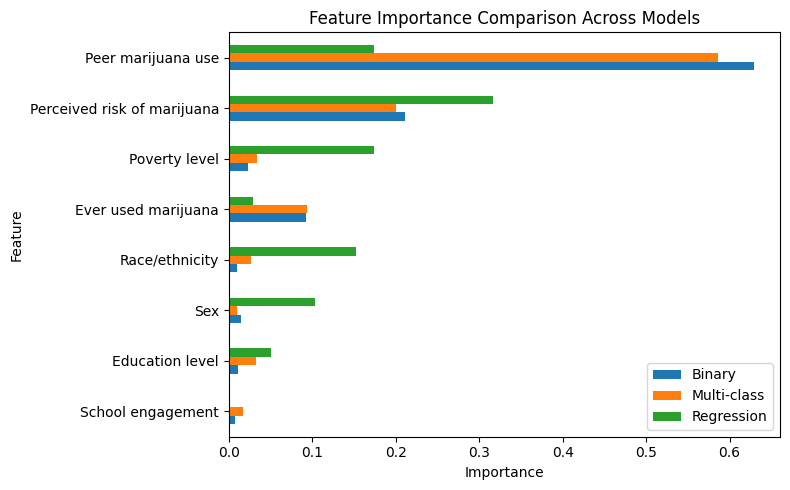

In [ ]:
# Get importances
imp_binary = tree_b.feature_importances_
imp_multi = tree_m.feature_importances_
imp_reg = tree_r.feature_importances_

# Map original variable names to readable labels
feature_names_map = {
    "POVERTY3": "Poverty level",
    "FRDMJMON": "Peer marijuana use",
    "PRMJEVR2": "Ever used marijuana",
    "STNDSMJ": "Perceived risk of marijuana",
    "SCHFELT": "School engagement",
    "EDUSCHGRD2": "Education level",
    "NEWRACE2": "Race/ethnicity",
    "IRSEX": "Sex"
}

# Use transformed feature names so lengths match
raw_features = binary_preprocessor.get_feature_names_out()

readable_features = []
for f in raw_features:
    # Remove transformer prefixes
    f_clean = f.replace("num__", "").replace("cat__", "")

    # Remove one-hot suffix
    base = f_clean.split("_")[0]

    # Map to readable name
    readable_features.append(feature_names_map.get(base, base))

# Create DataFrame with readable names
importance_df = pd.DataFrame({
    "Feature": readable_features,
    "Binary": imp_binary,
    "Multi-class": imp_multi,
    "Regression": imp_reg
})

# Combine duplicate rows from one-hot encoding
importance_df = importance_df.groupby("Feature", as_index=False).sum()

# Sort by average importance so order matches updated graph
importance_df["Avg"] = importance_df[["Binary", "Multi-class", "Regression"]].mean(axis=1)
importance_df = importance_df.sort_values(by="Avg", ascending=True)

# Plot
importance_df.set_index("Feature")[["Binary", "Multi-class", "Regression"]].plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Feature Importance Comparison Across Models")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Bagging (binary)

In [ ]:
# Bagging was tuned using GridSearchCV with 5-fold cross-validation, selecting the number of trees and base tree complexity based on accuracy
bag_param_grid = {
    "n_estimators": [50, 100, 200],
    "estimator__max_depth": [3, 4, 5],
    "estimator__min_samples_leaf": [10, 20, 50]
}

bag_grid = GridSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    param_grid=bag_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

bag_grid.fit(X_train_b, y_train_b)

print("Best bagging params:", bag_grid.best_params_)
print("Best bagging CV accuracy:", bag_grid.best_score_)

bag = bag_grid.best_estimator_
pred_bag = bag.predict(X_test_b)
pred_bag_proba = bag.predict_proba(X_test_b)[:, 1]

print("Bagging Accuracy:", accuracy_score(y_test_b, pred_bag))
print(confusion_matrix(y_test_b, pred_bag))
print(classification_report(y_test_b, pred_bag))
print("Bagging ROC AUC:", roc_auc_score(y_test_b, pred_bag_proba))

Best bagging params: {'estimator__max_depth': 5, 'estimator__min_samples_leaf': 20, 'n_estimators': 200}
Best bagging CV accuracy: 0.8946498926222933
Bagging Accuracy: 0.8883104590629437
[[1785   61]
 [ 175   92]]
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1846
           1       0.60      0.34      0.44       267

    accuracy                           0.89      2113
   macro avg       0.76      0.66      0.69      2113
weighted avg       0.87      0.89      0.87      2113

Bagging ROC AUC: 0.8740408454761992


## Random forest (multi-class)

In [ ]:
# Random Forest was tuned using GridSearchCV with 5-fold cross-validation, optimizing tree depth, number of trees, feature sampling, and leaf size.
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 5, 6],
    "min_samples_leaf": [10, 20, 50],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train_m, y_train_m)

print("Best RF multi params:", rf_grid.best_params_)
print("Best RF multi CV accuracy:", rf_grid.best_score_)

rf = rf_grid.best_estimator_
pred_rf = rf.predict(X_test_m)

print("Random Forest (Multi-class) Accuracy:", accuracy_score(y_test_m, pred_rf))
print(confusion_matrix(y_test_m, pred_rf))
print(classification_report(y_test_m, pred_rf))

Best RF multi params: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}
Best RF multi CV accuracy: 0.7618349851633086
Random Forest (Multi-class) Accuracy: 0.759110269758637
[[1531  170   83   62]
 [  38   37   40   39]
 [  19   19   23   27]
 [   4    4    4   13]]
              precision    recall  f1-score   support

           0       0.96      0.83      0.89      1846
           1       0.16      0.24      0.19       154
           2       0.15      0.26      0.19        88
           3       0.09      0.52      0.16        25

    accuracy                           0.76      2113
   macro avg       0.34      0.46      0.36      2113
weighted avg       0.86      0.76      0.80      2113



## Boosting (regression)

In [ ]:
# Boosting was tuned using GridSearchCV with 5-fold cross-validation, optimizing learning rate, number of trees, and tree depth based on RMSE
boost_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

boost_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=boost_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

boost_grid.fit(X_train_r, y_train_r)

print("Best boosting params:", boost_grid.best_params_)
print("Best boosting CV RMSE:", -boost_grid.best_score_)

boost = boost_grid.best_estimator_
pred_boost = boost.predict(X_test_r)

rmse_boost = np.sqrt(mean_squared_error(y_test_r, pred_boost))
print("Boosting RMSE:", rmse_boost)

Best boosting params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Best boosting CV RMSE: 40.44096999028676
Boosting RMSE: 35.24562063659491


## Model Comparison

### Binary Classification

In [ ]:
print("Decision Tree Accuracy:", accuracy_score(y_test_b, pred_b))
print("Bagging Accuracy:", accuracy_score(y_test_b, pred_bag))

print("\nDecision Tree ROC AUC:", roc_auc_score(y_test_b, tree_b.predict_proba(X_test_b)[:,1]))
print("Bagging ROC AUC:", roc_auc_score(y_test_b, pred_bag_proba))

Decision Tree Accuracy: 0.8883104590629437
Bagging Accuracy: 0.8883104590629437

Decision Tree ROC AUC: 0.8686886516448157
Bagging ROC AUC: 0.8740408454761992


### Regression

In [ ]:
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test_r, pred_r)))
print("Boosting RMSE:", rmse_boost)

print("\nDecision Tree MAE:", mean_absolute_error(y_test_r, pred_r))
print("Boosting MAE:", mean_absolute_error(y_test_r, pred_boost))

print("\nDecision Tree R^2:", r2_score(y_test_r, pred_r))
print("Boosting R^2:", r2_score(y_test_r, pred_boost))

Decision Tree RMSE: 35.6173670399263
Boosting RMSE: 35.24562063659491

Decision Tree MAE: 22.611894670314744
Boosting MAE: 22.849676214277498

Decision Tree R^2: -0.04053526402859342
Boosting R^2: -0.018928018156875837


## Feature importance

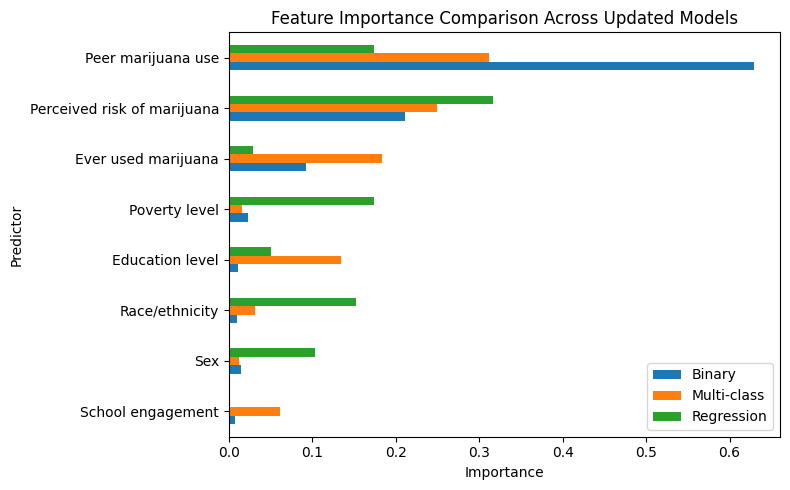

In [ ]:
# Compare feature importance across the updated tuned models

# Get importances
imp_binary = tree_b.feature_importances_
imp_multi = rf.feature_importances_
imp_reg = tree_r.feature_importances_

# Use transformed feature names
raw_features = binary_preprocessor.get_feature_names_out()

# Map original variable names to readable labels
feature_names_map = {
    "POVERTY3": "Poverty level",
    "FRDMJMON": "Peer marijuana use",
    "PRMJEVR2": "Ever used marijuana",
    "STNDSMJ": "Perceived risk of marijuana",
    "SCHFELT": "School engagement",
    "EDUSCHGRD2": "Education level",
    "NEWRACE2": "Race/ethnicity",
    "IRSEX": "Sex"
}

# Convert transformed names back to readable base names
readable_features = []
for f in raw_features:
    f_clean = f.replace("num__", "").replace("cat__", "")
    base = f_clean.split("_")[0]
    readable_features.append(feature_names_map.get(base, base))

# Build dataframe
importance_df = pd.DataFrame({
    "Feature": readable_features,
    "Binary": imp_binary,
    "Multi-class": imp_multi,
    "Regression": imp_reg
})

# Combine duplicated rows created by one-hot encoding
importance_df = importance_df.groupby("Feature", as_index=False).sum()

# Sort by average importance so bars are ordered
importance_df["Avg"] = importance_df[["Binary", "Multi-class", "Regression"]].mean(axis=1)
importance_df = importance_df.sort_values("Avg", ascending=True)

# Plot ordered comparison graph
importance_df.set_index("Feature")[["Binary", "Multi-class", "Regression"]].plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Feature Importance Comparison Across Updated Models")
plt.xlabel("Importance")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

## Tree visualization

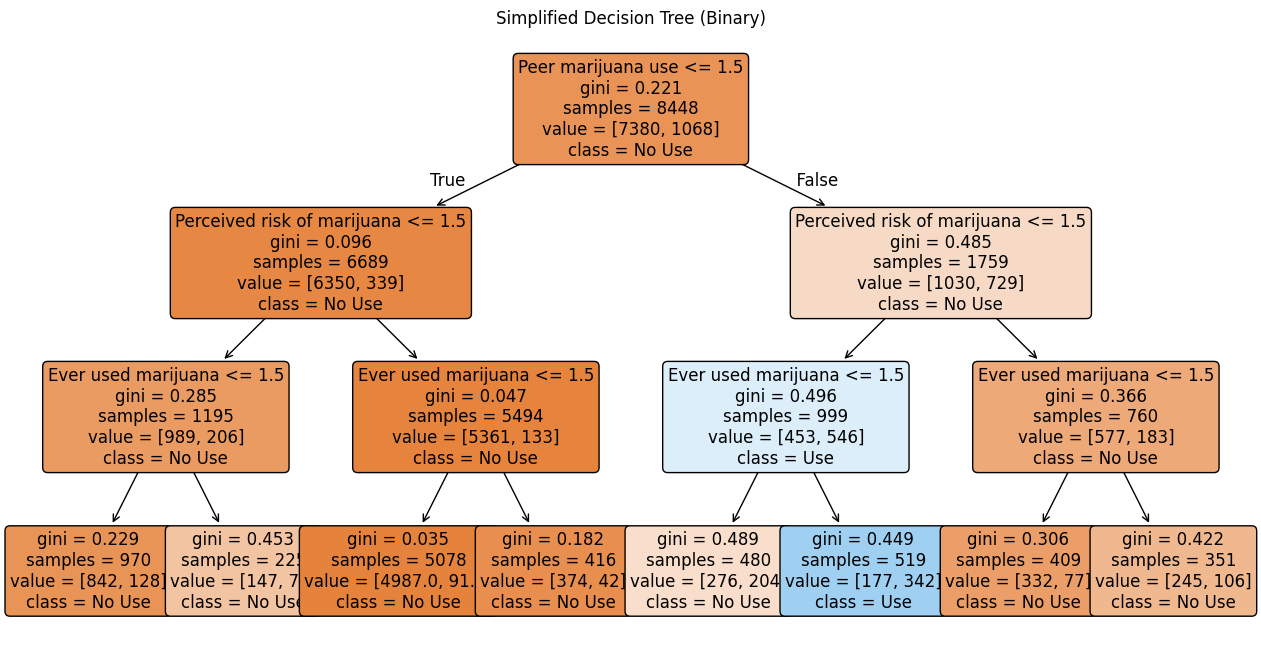

In [ ]:
# Apply mapping
readable_features = [
    feature_names_map.get(
        f.replace("num__", "").replace("cat__", "").split("_")[0],
        f.replace("num__", "").replace("cat__", "").split("_")[0]
    )
    for f in features
]

# Train simplified tree
display_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=50,
    random_state=42
)

display_tree.fit(X_train_b, y_train_b)

# Plot with readable labels
plt.figure(figsize=(16, 8))
plot_tree(
    display_tree,
    feature_names=readable_features,
    class_names=["No Use", "Use"],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title("Simplified Decision Tree (Binary)")
plt.show()